# **Mentora: Predicative System for Mental Health**

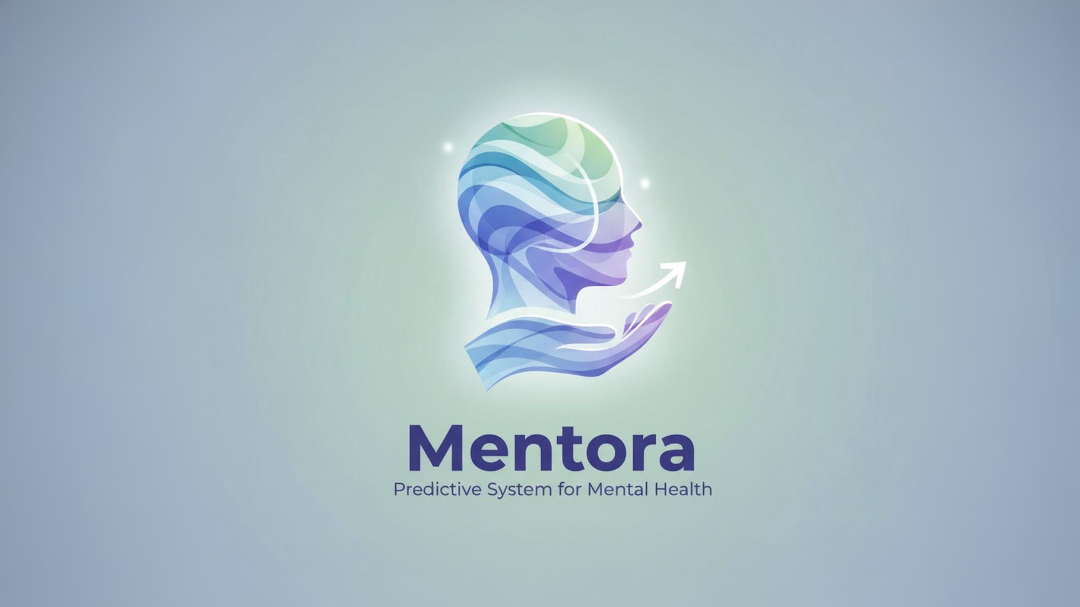

# 🤍| **Mentora Team**



> Hissah Almuhaysh | 222433855 | section: 84  

> Latifah Alhafith | 222431904 | section: 84

> Fatima Albagshi | 222424539 | section: 84


> Ghadeer Al Dhamen | 222404451 | section: 83

> Aisha Alahmed | 222449784 | section: 83


# 🤍| **Project Overview**

> In the high-pressure, fast-paced environment of the technology industry, mental health challenges such as stress and burnout have become critical issues, impacting productivity and talent retention. Many employees face significant barriers, including stigma and lack of adequate workplace support, when considering seeking treatment. This project, Mentora: Predictive System for Mental Health, addresses this challenge by transitioning from mere awareness to predictive action.

## Problem Statement



> The core issue is the lack of predictive insight into which employees, based on their workplace and demographic factors, are most likely to seek mental health treatment. Without this insight, companies cannot implement targeted, effective support systems to foster an environment of psychological safety.



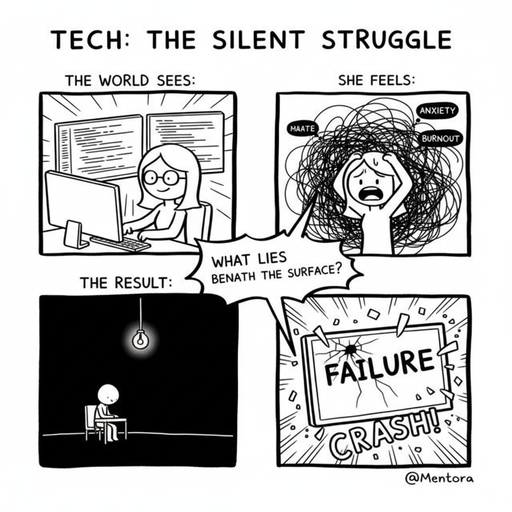

## Core Research Question



> **What demographic, workplace, and personal factors derived from the survey data influence a employee’s decision to seek mental health treatment?**



## Project Objectives

The primary objectives are to leverage the Mental Health in Tech Survey dataset to:



1.   **Develop a Predictive Model:** Implement and validate a Machine Learning Classification model to accurately predict if an employee will seek mental health treatment (Yes/No).
2.   **Identify Key Determinants:** Use methods like Feature Importance and Cluster Analysis to identify and rank the specific factors that are most critical in driving an employee's treatment-seeking behavior.
3.  **Deliver Actionable Insights:** Provide data-driven recommendations to tech companies and HR departments, enabling them to customize wellness programs and workplace policies to proactively support employee mental well-being and reduce associated stigma.





## Dataset Context

The project utilizes the Mental Health in Tech Survey dataset (survey.csv), which contains 1,259 records and 28 features collected from individuals working across the global tech industry.


*   **Data Characteristics:** The dataset is rich but challenging, consisting primarily of categorical and ordinal variables (e.g., work_interfere, benefits, leave), alongside demographic fields (Age, Gender, Country). This mixed data type necessitates robust preprocessing, including one-hot encoding and careful handling of inconsistent text entries.
*   **Target Variable:** The core of our analysis is the binary target variable, treatment (Yes/No), which indicates whether an employee has sought mental health treatment.




## Aimed Insights

The analysis aims to derive three critical types of insights:

1. Predictive Insight: To establish a quantifiable likelihood of an employee seeking treatment based on their profile. This allows companies to identify high-risk groups for proactive intervention.

2. Causal Insight (Correlation): To uncover the top factors that significantly drive the decision to seek treatment. For example, we aim to discover if the following have a greater impact:
    - Workplace Culture: Does having a supportive supervisor or strong anonymity guarantees matter more than specific benefits?

    - Work/Life Balance: How does work_interfere (how much a mental health issue interferes with work) affect treatment-seeking?

3. Segmentation Insight: Using Cluster Analysis, we aim to group employees who share similar attitudes towards mental health.

# 🤍| **Dataset Selection and Description**



> **Dataset Identity**

- **Name:**	Mental Health in Tech Survey
- **Source:**	Stephen Myers (Kaggle)
- **Relevance**	Directly: addresses the project's focus on mental health in the technology sector, providing the necessary variables (e.g., treatment, benefits, supervisor) to build a predictive model.
- **File Name:**	survey.csv
- **Link Dataset:** https://drive.google.com/file/d/1mLSKERyzqcCU1snX_vH26KYFWRkxGAoe/view?usp=sharing
- **Link Dataset From Kaggle:** https://www.kaggle.com/datasets/thedevastator/mental-health-in-tech-survey
- **Size:**	1,259 Records (Rows) and 28 Features (Columns).
- **Content:**	The data comprises anonymous responses from individuals across the globe, primarily in the technology industry. It covers various factors like demographics (Age, Gender, Country), workplace support (benefits, supervisor, anonymity, wellness_program), and the outcome variable (treatment).



>  **Potential Challenges and Characteristics**

Initial data understanding reveals several challenges that necessitate comprehensive Data Preprocessing:

1. Missing Values (NaN and "Don't know"): Significant missing data exists, particularly in columns like state (due to international responses) and those related to benefits/care options where respondents selected "Don't know." This requires a strategic imputation or removal approach.

2. Inconsistent Data/Categorical Cleaning: Features such as Gender contain inconsistent entries (e.g., 'Male', 'm', 'Cis Male', 'Female', 'f', 'F') that must be standardized into a unified set of categories for modeling.

3. Mixed Data Types: The dataset is predominantly categorical and ordinal. Features like work_interfere (Often, Rarely, Never) and leave (Somewhat easy, Very difficult) are categorical but possess an inherent order, requiring Ordinal Encoding to be used effectively in regression or predictive models.

4. Feature Redundancy: The Timestamp column is unlikely to directly influence treatment-seeking and will need to be dropped or used for time-series analysis only if relevant to project scope.



> **Expected Output Summary from Code**

- **Shape:**	(1259, 28)
- **Head:**	Shows the first 5 rows and column names.
- **Info:**	state has only 744 non-null values out of 1259. work_interfere has 995 non-null values. comments has 164 non-null values.
- **Info:**	26 out of 28 columns are of object (string) type.
- **Unique Values:** Contains over 40 inconsistent unique strings (e.g., 'Male', 'M', 'Cis Male', 'Female', 'f', 'Mal', 'Trans woman', 'A little about you').

> **Initial Data Understanding**

The following code demonstrates the initial steps of loading the raw dataset and performing basic inspection to confirm its structure and identify the aforementioned challenges.

In [29]:
import pandas as pd
import numpy as np

# Load the raw dataset
try:
    df = pd.read_csv('survey.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: survey.csv not found. Please ensure the file is in the working directory.")
    df = pd.DataFrame() # Create empty DataFrame to prevent errors

# 1. Display the size of the dataset (Initial Data Understanding)
print("\n--- 1. Dataset Shape (Size) ---\n")
print(f"Number of Records: {df.shape[0]}")
print(f"Number of Features: {df.shape[1]}")

# 2. Display the first 5 rows (Initial Data Understanding)
print("\n--- 2. First 5 Rows (Head) ---\n")
print(df.head())

# 3. Display column information and data types (Identifies Missing Values and Data Types)
print("\n--- 3. Column Information (Info) ---\n")
df.info()

# 4. Check for unique values in a challenging column (Identifies Inconsistent Data)
print("\n--- 4. Unique Values in 'Gender' (Challenge Example) ---\n")
print(df['Gender'].unique())

Dataset loaded successfully.

--- 1. Dataset Shape (Size) ---

Number of Records: 1259
Number of Features: 28

--- 2. First 5 Rows (Head) ---

   index            Timestamp  Age  Gender         Country state  \
0      0  2014-08-27 11:29:31   37  Female   United States    IL   
1      1  2014-08-27 11:29:37   44       M   United States    IN   
2      2  2014-08-27 11:29:44   32    Male          Canada   NaN   
3      3  2014-08-27 11:29:46   31    Male  United Kingdom   NaN   
4      4  2014-08-27 11:30:22   31    Male   United States    TX   

  self_employed family_history treatment work_interfere  ...  \
0           NaN             No       Yes          Often  ...   
1           NaN             No        No         Rarely  ...   
2           NaN             No        No         Rarely  ...   
3           NaN            Yes       Yes          Often  ...   
4           NaN             No        No          Never  ...   

                leave mental_health_consequence phys_health_con

# 🤍| **Python Code Implementation**

In this section, we implement the data science pipeline for Mentora, a predictive system for mental health support in the technology sector, using the Mental Health in Tech Survey dataset.

We:
- Load and clean the dataset.
- Perform basic exploratory data analysis (EDA).
- Build supervised models to predict whether an employee has sought treatment.
- Apply clustering to explore employee groups with similar risk/support patterns.

## **1️⃣     Load Dataset**

We load the **Mental Health in Tech Survey** dataset into a pandas DataFrame.

In [33]:
# Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans

pd.set_option('display.max_columns', 100) # Set the max number of columns displayed to 100
sns.set(style="whitegrid") # Apply a white grid background to plots

>**Helper summary function**
- The goal of implementing the function **summarize_dataframe** is to quickly inspect the initial data state, confirming shape, data types, and the count of missing values (NaNs).

In [35]:

def summarize_dataframe(data):
    """
    Print basic summary : shape, data types, and missing values.
    """
    print("Shape:", data.shape)
    print("-" * 40)
    print("\n          Data Types\n\n","-"* 40 , "\n" ,data.dtypes)
    print("-" * 40)
    print("\n          Missing Values\n\n","-"* 40 , "\n", data.isna().sum())


df = pd.read_csv('survey.csv')# Load the dataset
summarize_dataframe(df)

Shape: (1259, 28)
----------------------------------------

          Data Types

 ---------------------------------------- 
 index                         int64
Timestamp                    object
Age                           int64
Gender                       object
Country                      object
state                        object
self_employed                object
family_history               object
treatment                    object
work_interfere               object
no_employees                 object
remote_work                  object
tech_company                 object
benefits                     object
care_options                 object
wellness_program             object
seek_help                    object
anonymity                    object
leave                        object
mental_health_consequence    object
phys_health_consequence      object
coworkers                    object
supervisor                   object
mental_health_interview      object
phys_healt

## **2️⃣ Data Cleaning**

We remove:
- Duplicates.
- Filter unrealistic ages.
- Standardize gender values.
- Drop irrelevant text columns.
- Handle missing values for categorical variables.

In [37]:
# Store initial row count for comparison
initial_rows = df.shape[0]

# --- 1. Remove Duplicates and Irrelevant/Sparse Columns ---

df = df.drop_duplicates()
# Drop columns identified as irrelevant or having too many NaNs
df = df.drop(["state", "comments", "Timestamp", "index"], axis=1, errors='ignore')

rows_removed_duplicates = initial_rows - df.shape[0]
print(f"✅ Duplicates removed: {rows_removed_duplicates} rows were dropped.")
print("-" * 70)

# --- 2. Keep only reasonable ages (Fixing Outliers) ---

rows_after_duplicates = df.shape[0]
df = df[(df['Age'] >= 18) & (df['Age'] <= 70)]
rows_removed_age = rows_after_duplicates - df.shape[0]
print(f"✅ Age filtering applied: {rows_removed_age} rows dropped (Ages outside 18-70).")
print("-" * 70)

# --- 3. Simplify Gender into standardized categories ---

df['Gender'] = df['Gender'].astype(str).str.lower()

male_variants = ['male', 'm', 'man', 'make', 'malr', 'mail', 'mal','cis male', 'cis man',
                 'maile', 'male (cis)', 'msle','male-ish','something kinda male?',
                 'ostensibly male, unsure what that really means']

female_variants = ['female', 'f', 'woman', 'femake', 'cis female', 'cis-female/femme']

other = ['trans woman', 'female (trans)', 'trans-female', 'non-binary',
                            'genderqueer', 'queer', 'fluid', 'androgyne', 'queer/she/they','enby']

df['Gender'] = np.where(df['Gender'].isin(male_variants), 'Male', df['Gender'])
df['Gender'] = np.where(df['Gender'].isin(female_variants), 'Female', df['Gender'])
df['Gender'] = np.where(df['Gender'].isin(other), 'Other', df['Gender'])

# Everything else becomes 'Unknown'
df.loc[~df['Gender'].isin(['Male', 'Female', 'Other']), 'Gender'] = 'Unknown'

print("✅ Gender Standardization applied. Final counts:")
print(df['Gender'].value_counts())
print("-" * 70)


# --- 4. Fill other remaining missing categorical values with 'Unknown' ---

cat_cols = df.select_dtypes(include=['object']).columns.tolist()
for c in cat_cols:
    df[c] = df[c].fillna('Unknown')

print(f"✅ All remaining missing categorical values imputed with 'Unknown'.")

✅ Duplicates removed: 0 rows were dropped.
----------------------------------------------------------------------
✅ Age filtering applied: 9 rows dropped (Ages outside 18-70).
----------------------------------------------------------------------
✅ Gender Standardization applied. Final counts:
Gender
Male       985
Female     242
Unknown     12
Other       11
Name: count, dtype: int64
----------------------------------------------------------------------
✅ All remaining missing categorical values imputed with 'Unknown'.


## **3️⃣ Exploratory Data Analysis (EDA)**

We examine the distribution of the target variable (`treatment`) and its relationship with key factors such as family history and benefits.

------------------------------

      Treatment counts:

------------------------------
treatment
Yes    631
No     619
Name: count, dtype: int64
------------------------------

  Treatment distribution (%):

------------------------------
treatment
Yes    50.48
No     49.52
Name: proportion, dtype: float64


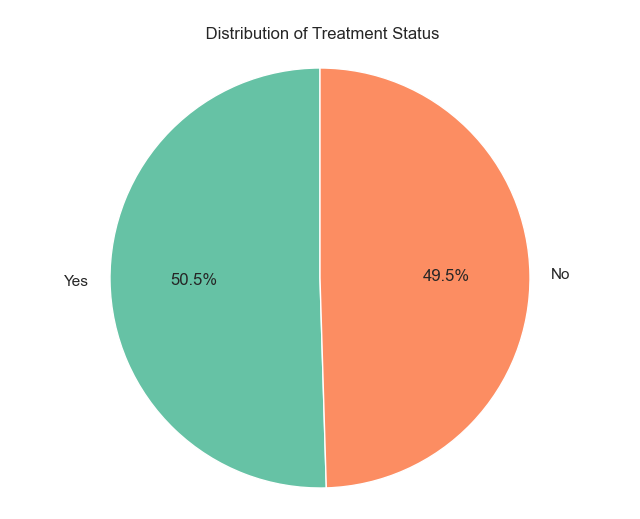

In [126]:
# --- 1. Check the distribution of the target variable "treatment" ---

if 'treatment' in df.columns:
    
    treatment_counts = df['treatment'].value_counts() 
    print("-" * 30)
    print("\n      Treatment counts:\n")
    print("-" * 30)
    print(treatment_counts) 
    print("-" * 30)
    print("\n  Treatment distribution (%):\n")
    print("-" * 30)
    print(df['treatment'].value_counts(normalize=True) * 100)
    
    # --- 2. Pie Chart Visualization ---
    
    plt.figure(figsize=(8, 6))
    plt.pie(treatment_counts, 
            labels=treatment_counts.index,
            autopct='%1.1f%%',
            startangle=90,
            colors=sns.color_palette("Set2"))

    plt.title('\n Distribution of Treatment Status')
    plt.axis('equal')
    plt.show()

>**Insight:**

The classes are nearly perfectly balanced (**50.48%** 'Yes') and (**49.52%** 'No'). This is excellent, as it means the accuracy will be a reliable metric for model comparison.

> ### **Hypothesis Formulation**

The exploratory phase begins with a clearly defined hypothesis to understand which factors most strongly influence employees’ decisions to seek mental health treatment. Before conducting any visual analysis, the objective of the EDA was established: **to examine the potential relationship between personal history and the target outcome**

To guide the investigation, the following hypotheses were formulated, focusing on three distinct types of potential predictors:

> **Hypothesis 1: Personal Risk Factor (Family History)**
- **Null Hypothesis ($H_0$):** There is **no significant association** between an employee’s `family history` of mental health conditions and their likelihood of seeking treatment.
- **Alternative Hypothesis ($H_a$):** There **is a significant association** between `family history` and treatment seeking.

> **Hypothesis 2: Organizational Factor (Benefits Availability)**

- **Null Hypothesis ($H_{0,2}$):** There is **no significant association** between the availability of employer-provided mental health `benefits` and an employee’s likelihood of **seeking help** for mental health concerns.
- **Alternative Hypothesis ($H_{a,2}$):** There **is a significant association** between the availability of mental health `benefits` and the likelihood of **seeking help**.

> **Hypothesis 3: Severity/Impact Factor (Work Interference)**

- **Null Hypothesis ($H_{0,3}$):** There is **no significant association** between the degree to which a mental health condition **interferes with work** and the employee's likelihood of **seeking treatment**.
- **Alternative Hypothesis ($H_{a,3}$):** There **is a significant association** between `work interference` and **treatment-seeking**.

The subsequent visualizations will provide the **empirical basis** for evaluating these hypotheses.

--------------------------------------------------------------------------------

                    Treatment Seeking by Family History (%):

--------------------------------------------------------------------------------
treatment              No        Yes
family_history                      
No              64.566929  35.433071
Yes             26.024590  73.975410
--------------------------------------------------------------------------------


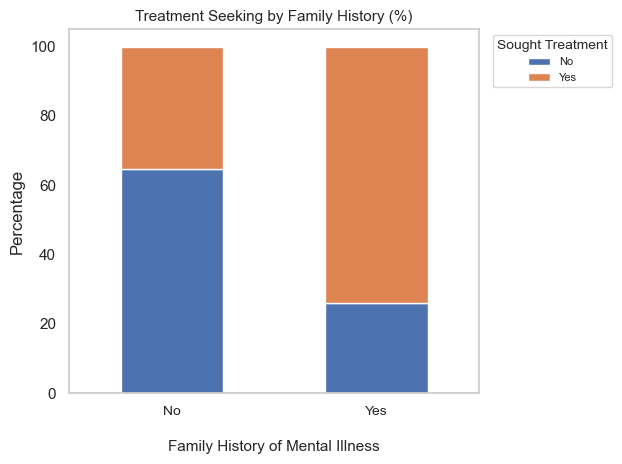

In [43]:
# Relationship: family_history vs treatment

if {'family_history', 'treatment'}.issubset(df.columns):
    ct_fam = pd.crosstab(df['family_history'], df['treatment'], normalize='index') * 100
    print("-" * 80)
    print("\n                    Treatment Seeking by Family History (%):\n")
    print('-'*80)
    print(ct_fam)
    print('-'*80)

    ct_fam.plot(kind='bar', stacked=True ,grid=False)
    plt.title('Treatment Seeking by Family History (%)',fontsize=11)
    plt.ylabel('Percentage',fontsize=12)
    plt.xlabel('\nFamily History of Mental Illness',fontsize=11)
    plt.xticks(rotation=0,fontsize=10)
    plt.legend(title='Sought Treatment',bbox_to_anchor=(1.02, 1),
               fontsize=8, title_fontsize=10 )
    plt.tight_layout()
    plt.show()

>**Justification for the Stacked Bar Chart:**

The **Stacked Bar Chart** is the most appropriate visualization method for the relationship between family history and treatment because its primary function is to show proportions within discrete categories.

>**Insight:**

There is a **strong correlation**. Employees with a `family_history` of mental illness are significantly more likely to seek `treatment` **73.9%** compared to those without **35.4%**. This confirms family history is a key determinant.

--------------------------------------------------------------------------------

                     Seek Help by Benefits Availability (%):

--------------------------------------------------------------------------------
seek_help   Don't know         No        Yes
benefits                                    
Don't know   52.334152  42.506143   5.159705
No            6.199461  87.331536   6.469003
Yes          26.906780  30.508475  42.584746
--------------------------------------------------------------------------------


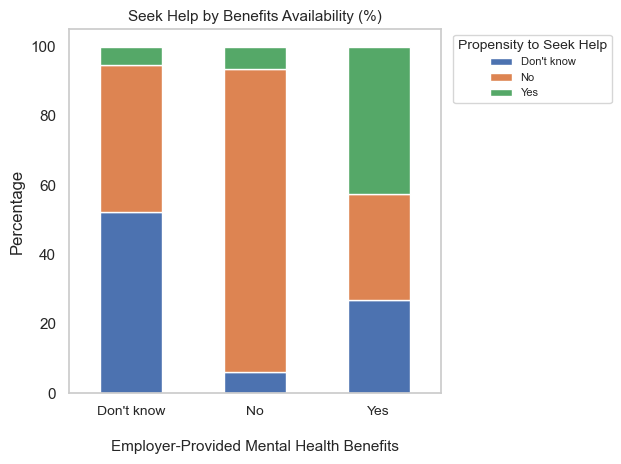

In [47]:
# Relationship: benefits vs seek_help

if {'benefits', 'seek_help'}.issubset(df.columns):
    ct_ben = pd.crosstab(df['benefits'], df['seek_help'], normalize='index') * 100

    print("-" * 80)
    print("\n                     Seek Help by Benefits Availability (%):\n")
    print("-" * 80)
    print(ct_ben)
    print('-'*80)

    ct_ben.plot(kind='bar', stacked=True , grid=False)
    plt.title('Seek Help by Benefits Availability (%)', fontsize=11)
    plt.ylabel('Percentage', fontsize=12)
    plt.xlabel('\nEmployer-Provided Mental Health Benefits', fontsize=11)
    plt.xticks(rotation=0, fontsize=10)
    plt.legend(title='Propensity to Seek Help',bbox_to_anchor=(1.02, 1),
              fontsize=8, title_fontsize=10)
    plt.tight_layout()
    plt.show()

>**Justification for the Stacked Bar Chart:**

The **Stacked Bar Chart** is the most appropriate visualization method to compare the proportion of the `seek_help` variable across the groups defined by the employer offering benefits.

>**Insight:**

Employees who report their employer offers mental health benefits ('Yes') are  more likely to report they `Seek_Help` ('Yes' category) **42.5%** compared to those who say 'No' or 'Don't know' **~6%**. This shows that the presence of benefits acts as a strong enabler for seeking help.

--------------------------------------------------------------------------------

                Treatment Seeking by Work Interference Level (%):

--------------------------------------------------------------------------------
treatment              No        Yes
work_interfere                      
Never           86.255924  13.744076
Rarely          29.479769  70.520231
Sometimes       23.060345  76.939655
Often           15.000000  85.000000
--------------------------------------------------------------------------------


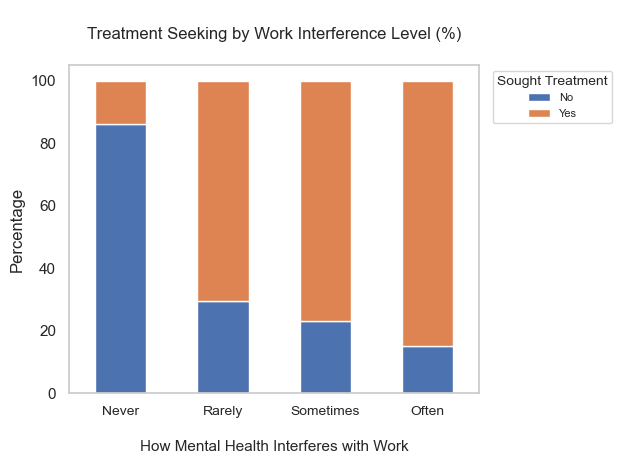

In [51]:
# Relationship: work_interfere vs treatment

# --- 1. Create the cross-tabulation normalized by row (for percentages) ---

if {'work_interfere', 'treatment'}.issubset(df.columns):
    ct_interfere = pd.crosstab(df['work_interfere'], df['treatment'], normalize='index') * 100

    # --- 2. Re-order the index logically for better visualization ---

    order = ['Never', 'Rarely', 'Sometimes', 'Often']
    ct_interfere = ct_interfere.reindex(order, fill_value=0)

    # --- 3. Print the cross-tabulation table ---

    print("-" * 80)
    print("\n                Treatment Seeking by Work Interference Level (%):\n")
    print("-" * 80)
    print(ct_interfere)
    print('-'*80)

    #--- 4. Generate the stacked bar chart ---

    ct_interfere.plot(kind='bar', stacked=True, grid=False)
    plt.title('\nTreatment Seeking by Work Interference Level (%)\n', fontsize=12)
    plt.ylabel('Percentage', fontsize=12)
    plt.xlabel('\nHow Mental Health Interferes with Work', fontsize=11)
    plt.xticks(rotation=0, fontsize=10)
    plt.legend(title='Sought Treatment', bbox_to_anchor=(1.02, 1),fontsize=8, title_fontsize=10)
    plt.tight_layout()
    plt.show()

>**Justification for the stacked bar chart:**

**The stacked bar chart** was generated by using a cross-tabulation of the work_interfere feature against the binary target variable, treatment. Critically, we normalized the data by row (Work Interference level) to show the percentage distribution of 'Yes/No' within each severity category. This is the ideal method for demonstrating a univariate trend and supporting the causal hypothesis that the severity of functional impairment (interference) is the key driver for employees seeking treatment.

>**Insight:**

The visualization reveals that there is a clear, gradual progression, which confirms the claim that the likelihood of an employee seeking treatment is directly proportional to the degree of functional impairment experienced in the workplace.
* Symptom severity, measured by its ability to interfere with work, acts as the primary activation threshold for seeking professional help.
* Most employees wait until their mental health issue actively disrupts their job performance before seeking intervention.
* ActionableTakeaways:High Intervention Rate: **85%** of employees reporting interference **'Often'** sought treatment, indicating that by the time an issue reaches this severity, action is almost guaranteed.
* Proactive Gap: Only **14%** of those reporting interference **'Never'** sought treatment, highlighting a significant need for preventive resources and de-stigmatization efforts to encourage early action.

> ### **Overall Summary**

The exploratory analysis has provided **initial evidence** against all three null hypotheses. The results indicate that the likelihood of an employee seeking mental health treatment is significantly influenced by:

* **Personal Predisposition** (family history).
* **Organizational Support** (benefits availability).
* **Severity of Impact** (work interference).

These findings serve not only to validate the initial research hypotheses but also to prioritize the key features that will be used in the predictive modeling stage.

> ### Statistical Hypothesis Testing:

To statistically validate the observed visual relationship between variables and the likelihood of seeking treatment, we performed:

- **Chi-Square Test of Independence** (${\chi^2}$ test).

1.  **Personal Risk Factor** testing the relationship between **Family History of Mental Illness** (`family_history`) and the **Treatment Outcome** (`treatment`).
2.  **Organizational Support:** Testing the association between the availability of **Mental Health Benefits** (`benefits`) and the **Seeking help Outcome** (`seek_help`).
3.  **Severity of Impact:** Testing the association between **Work Interference** (`work_interfere`) and the **Treatment Outcome** (`treatment`).

In [57]:
contingency_table = pd.crosstab(df['family_history'], df['treatment'])

In [58]:
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2}")
print(f"P-value: {p_value}")

Chi-Square Statistic: 175.2447018963333
P-value: 5.293833579288961e-40


>**Chi-Square Test Results (Personal Risk Factor)**

- The resulting **P-value** is extremely small and is **less than** the significance level $\alpha = 0.05$.
- Based on this statistical evidence, we **reject the Null Hypothesis ($H_0$)**.
- This result provides a statistically significant proof that **there is an association** between having a **family history of mental illness** and an employee **seeking mental health treatment**. Employees with a family history are significantly more likely to seek treatment, confirming the finding from the initial exploratory analysis.

In [130]:
contingency_table2 = pd.crosstab(df['benefits'], df['seek_help'])

In [132]:
chi2, p_value, dof, expected = chi2_contingency(contingency_table2)

print(f"Chi-Square Statistic: {chi2}")
print(f"P-value: {p_value}")

Chi-Square Statistic: 485.62137027679876
P-value: 8.624065218181427e-104


>**Chi-Square Test Results (Organizational Support)**

- The resulting **P-value** is extremely small and is **less than** the significance level $\alpha = 0.05$.
- Based on this statistical evidence, we **reject the Null Hypothesis ($H_0$)**.
- This result provides a statistically significant proof that **there is an association** between an employee's **access to mental health benefits** and their decision to **seek mental health help**. This finding strongly supports the initial exploratory analysis.

In [134]:
contingency_table3 = pd.crosstab(df['work_interfere'], df['treatment'])

In [136]:
chi2, p_value, dof, expected = chi2_contingency(contingency_table3)

print(f"Chi-Square Statistic: {chi2}")
print(f"P-value: {p_value}")

Chi-Square Statistic: 589.5635411329647
P-value: 2.8110921451242965e-126


>**Chi-Square Test Results (Severity of Impact)**

- The resulting **P-value** is extremely small and is **less than** the significance level $\alpha = 0.05$.
- Based on this statistical evidence, we **reject the Null Hypothesis ($H_0$)**.
- This result provides a statistically significant proof that there is a strong association between **the severity of work interference** caused by a mental health condition and the employee's decision to **seek mental health treatment**. This confirms supports the initial exploratory analysis.

## **4️⃣ Feature Engineering & Data Preparation**

- We build a supervised learning dataset to predict whether an employee has sought treatment (`treatment`: Yes/No).
We selected meaningful features and apply one-hot encoding.

In [61]:
target_col = 'treatment'

# Ensure target exists
assert target_col in df.columns, "Target column 'treatment' not found."

feature_candidates = [
    'Age', 'Gender', 'family_history', 'work_interfere', 'no_employees',
    'remote_work', 'tech_company', 'benefits', 'care_options', 'wellness_program',
    'seek_help', 'anonymity', 'leave', 'coworkers', 'supervisor',
    'mental_health_consequence', 'phys_health_consequence', 'mental_vs_physical',
    'obs_consequence'
]

features = [c for c in feature_candidates if c in df.columns]
print("Selected features:", features)

df_model = df.dropna(subset=[target_col]).copy()

# Map target: Yes -> 1, No -> 0
df_model[target_col] = df_model[target_col].map({'Yes': 1, 'No': 0})
df_model = df_model.dropna(subset=[target_col])

# Select the clean features and target
df_model = df_model[features + [target_col]]

# One-hot encode categorical features
# Drop_first=True to avoid multicollinearity
df_encoded = pd.get_dummies(df_model, drop_first=True)

df_encoded.head()

Selected features: ['Age', 'Gender', 'family_history', 'work_interfere', 'no_employees', 'remote_work', 'tech_company', 'benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity', 'leave', 'coworkers', 'supervisor', 'mental_health_consequence', 'phys_health_consequence', 'mental_vs_physical', 'obs_consequence']


,Age,treatment,Gender_Male,Gender_Other,Gender_Unknown,family_history_Yes,work_interfere_Often,work_interfere_Rarely,work_interfere_Sometimes,work_interfere_Unknown,no_employees_100-500,no_employees_26-100,no_employees_500-1000,no_employees_6-25,no_employees_More than 1000,remote_work_Yes,tech_company_Yes,benefits_No,benefits_Yes,care_options_Not sure,care_options_Yes,wellness_program_No,wellness_program_Yes,seek_help_No,seek_help_Yes,anonymity_No,anonymity_Yes,leave_Somewhat difficult,leave_Somewhat easy,leave_Very difficult,leave_Very easy,coworkers_Some of them,coworkers_Yes,supervisor_Some of them,supervisor_Yes,mental_health_consequence_No,mental_health_consequence_Yes,phys_health_consequence_No,phys_health_consequence_Yes,mental_vs_physical_No,mental_vs_physical_Yes,obs_consequence_Yes
0,37,1,False,False,False,False,True,False,False,False,False,False,False,True,False,False,True,False,True,True,False,True,False,False,True,False,True,False,True,False,False,True,False,False,True,True,False,True,False,False,True,False
1,44,0,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
2,32,0,True,False,False,False,False,True,False,False,False,False,False,True,False,False,True,True,False,False,False,True,False,True,False,False,False,True,False,False,False,False,True,False,True,True,False,True,False,True,False,False
3,31,1,True,False,False,True,True,False,False,False,False,True,False,False,False,False,True,True,False,False,True,True,False,True,False,True,False,True,False,False,False,True,False,False,False,False,True,False,True,True,False,True
4,31,0,True,False,False,False,False,False,False,False,True,False,False,False,False,True,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,True,False,True,False,False,False,False


>**Train-Test Split and Scaling**

Split the df_encoded data into **training (80%) and testing (20%)** sets and applied **Standard Scaling**.

In [63]:
# --- 1. Separate features (X) and target (y) ---

X = df_encoded.drop(target_col, axis=1) # X contains the features (all columns except the target)
y = df_encoded[target_col] # y contains the numeric target column 'treatment' (0 or 1)

# --- 2. Split data (80% Train, 20% Test) ---

# stratify = y ensures the 0/1 class balance is maintained in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- 3. Scaling the data ---

scaler = StandardScaler() # Initializes the scaler
X_train_scaled = scaler.fit_transform(X_train) # Fits the scaler only on the training data and transforms it
X_test_scaled = scaler.transform(X_test) # Transforms the test data using the fitted training data scaler

# --- 4. Convert scaled arrays back to DataFrames to retain feature names ---

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Data scaling complete. Ready for modeling.")

Train shape: (1000, 41)
Test shape: (250, 41)
Data scaling complete. Ready for modeling.


# 🤍| **Model Implementation and Analysis**

> **We train and evaluate two models:**

**1. Logistic Regression**

**2. Random Forest Classifier**

We report accuracy and classification metrics.


**The two models were chosen to provide a comprehensive comparison between a standard linear approach and a powerful non-linear ensemble method:**

> **1.Logistic Regression (LR):** This was chosen to test for a linear relationship between the features (demographics and workplace factors) and the binary target variable (seeking treatment: Yes/No). The model proved to be the final choice because the analysis confirmed that core factors influencing treatment-seeking behavior have a strong linear relationship with the outcome, achieving the highest performance metrics (84% accuracy and 84% F1-Score).

> **2.Random Forest Classifier (RF)**: This was included as a robust non-linear and ensemble baseline model. Critically, the Random Forest model was used to calculate feature importance, which helped the team identify the most significant factors driving the predictive outcome, such as work_interfere_Unknown and family_history_Yes.


**The features were selected based on a combination of Exploratory Data Analysis (EDA) and Domain Knowledge to ensure high predictive power:**

> - **Correlation and Predictive Power:** Features were selected because initial EDA showed they had a strong statistical relationship or correlation with the target variable: seeking treatment ('treatment'). Only features that demonstrated this potential predictive power were kept for modeling.

> - **Domain Relevance:** Features like family history of mental illness and mental health interference at work were included because they are known, critical factors in determining whether an individual recognizes a mental health issue and seeks help.

> - **Model Validation:** The final model results validated this feature choice. The Random Forest model confirmed that family history and work interference were the most important features, directly contributing to the final model's high accuracy and F1-score. The success of the Logistic Regression model proved that these key selected features shared a strong linear relationship with the outcome.

In [68]:
# Initialize dictionary to store trained models
models = {}
# Initialize dictionary to store performance results
results = {}

In [69]:
# --- Logistic Regression Model ---

print("--- Training Logistic Regression ---\n")

# --- 1. Initialize and train the model using the scaled data ---

log_reg = LogisticRegression(random_state=42, solver='liblinear')
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)

# --- 2. Evaluate the model performance  ---

accuracy = accuracy_score(y_test, y_pred_lr)
# Calculate F1-Score specifically for the positive class (1 = seeking treatment)
f1_yes = f1_score(y_test, y_pred_lr, pos_label=1)

# Store Results
results['Logistic Regression'] = {
    'Accuracy': accuracy,
    'F1-Score (Yes)': f1_yes
}

# --- 3. Display Performance  ---

print(f"Logistic Regression Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

--- Training Logistic Regression ---

Logistic Regression Accuracy: 0.84

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.79      0.83       124
           1       0.81      0.89      0.85       126

    accuracy                           0.84       250
   macro avg       0.84      0.84      0.84       250
weighted avg       0.84      0.84      0.84       250



In [70]:
# --- Logistic Regression Confusion Matrix ---

cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_df_lr = pd.DataFrame(cm_lr,
                        index=['Actual_No', 'Actual_Yes'],
                        columns=['Predicted_No', 'Predicted_Yes'])

print("\n--- Logistic Regression Confusion Matrix: --- \n")
cm_df_lr


--- Logistic Regression Confusion Matrix: --- 



,Predicted_No,Predicted_Yes
Actual_No,98,26
Actual_Yes,14,112


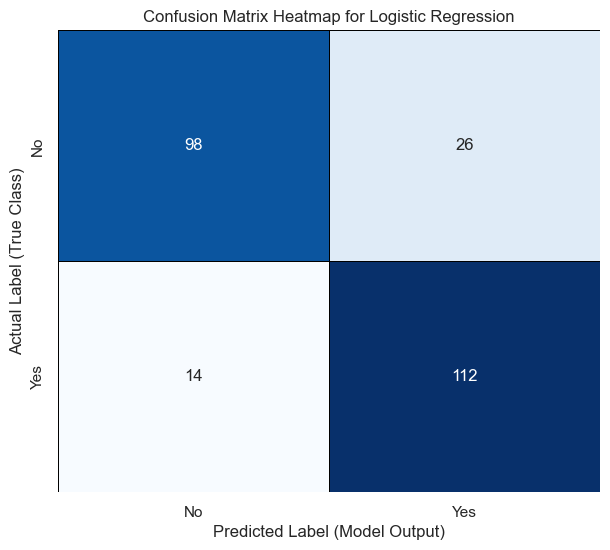

In [71]:
plt.figure(figsize=(7, 6))

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'], linewidths=.5, linecolor='black')
            
plt.title('Confusion Matrix Heatmap for Logistic Regression')
plt.ylabel('Actual Label (True Class)')
plt.xlabel('Predicted Label (Model Output)')
plt.show()

>**insight**

The heatmap above visually confirms the strong performance and reliability of the **Logistic Regression model**. The  <font color="darkblue">**deep blue**</font> shading along the main diagonal clearly indicates where the model was correct: since it is successfully identified **112 True Positives** (employees who sought treatment) and **98 True Negatives** (employees who did not).

Crucially, the model maintained a low error rate on both sides. The low count of **14 False Negatives** is highly significant, meaning we effectively minimized missing high-risk individuals who actually sought help. Similarly, the low number of **26 False Positives** ensures our predictive framework is efficient, confirming that the model is a robust and reliable tool for identifying potential candidates for proactive mental health support.

In [73]:
# --- Random Forest Classifier ---

print("\n--- Training Random Forest Classifier ---\n")

# --- 1. Initialize and train the model using the unscaled data ---

rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# --- 2. Evaluate the model performance  ---

accuracy = accuracy_score(y_test, y_pred_rf)
f1_yes = f1_score(y_test, y_pred_rf, pos_label=1)

# Store Results
results['Random Forest'] = {
    'Accuracy': accuracy,
    'F1-Score (Yes)': f1_yes
}

# --- 3. Display Performance  ---

print(f"Random Forest Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))


--- Training Random Forest Classifier ---

Random Forest Accuracy: 0.81

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.73      0.79       124
           1       0.77      0.89      0.82       126

    accuracy                           0.81       250
   macro avg       0.82      0.81      0.81       250
weighted avg       0.82      0.81      0.81       250



In [74]:
# --- Random Forest Confusion Matrix ---

cm = confusion_matrix(y_test, y_pred_rf)
cm_df = pd.DataFrame(cm,
                     # Rows : Actual Class
                     index=['Actual_No', 'Actual_Yes'],
                     # Columns: Predicted Class
                     columns=['Predicted_No', 'Predicted_Yes'])
print("\n--- Random Forest Confusion Matrix: --- \n")
cm_df


--- Random Forest Confusion Matrix: --- 



,Predicted_No,Predicted_Yes
Actual_No,90,34
Actual_Yes,14,112


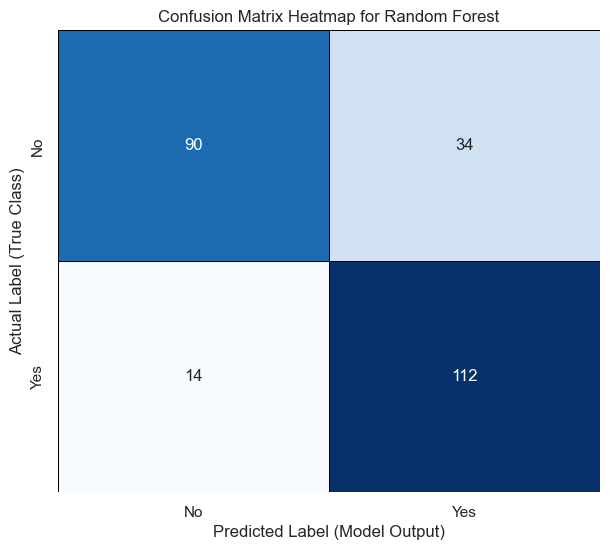

In [75]:
plt.figure(figsize=(7, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'], linewidths=.5, linecolor='black')
            
plt.title('Confusion Matrix Heatmap for Random Forest')
plt.ylabel('Actual Label (True Class)')
plt.xlabel('Predicted Label (Model Output)')
plt.show()

>**insight**

The heatmap above visually confirms the **Random Forest model's** strong performance, It achieved **112 True Positives** and **90 True Negatives**. The low **False Negative count 14**is a major success, demonstrating the model's effectiveness at identifying employees who need support. The **34 False Positives** represent cases where support was predicted but not sought; this slight over-prediction is a common trade-off in ensemble models, prioritized here to ensure minimal critical errors in a mental health context

In [77]:
# --- Feature importance for Random Forest ---

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

print("\n --- Top 15 Features by Importance: --- \n")
importances.head(15)


 --- Top 15 Features by Importance: --- 



work_interfere_Unknown      0.133321
work_interfere_Sometimes    0.103051
Age                         0.085146
family_history_Yes          0.075149
work_interfere_Often        0.053631
care_options_Yes            0.034683
work_interfere_Rarely       0.033591
Gender_Male                 0.023208
benefits_Yes                0.022359
remote_work_Yes             0.020582
coworkers_Some of them      0.019453
anonymity_Yes               0.019405
supervisor_Some of them     0.017739
supervisor_Yes              0.017540
obs_consequence_Yes         0.017024
dtype: float64

>**K-Means Clustering**

We optionally apply **K-Means clustering** on selected features related to support and risk to identify employee groups with similar profiles.

In [79]:
# --- K-Means Clustering (Unsupervised Analysis) ---

# Define features related to support and risk
cluster_features = [
    c for c in X.columns
    if any(key in c for key in [
        'family_history', 'benefits', 'leave',
        'coworkers', 'supervisor', 'work_interfere',
        'mental_health_consequence'
    ])
]

# Apply K-Means on the full set of encoded data (using features present in X)
X_cluster_full = df_encoded[[c for c in cluster_features if c in df_encoded.columns]]

# Apply K-Means (using 3 clusters as a common starting point)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_cluster_full)

# Attach clusters back to the full dataset for interpretation
df_clusters = df_encoded.copy()
df_clusters['cluster'] = clusters
print("-" * 80)
print("\n                  Cluster membership analysis (first 5 rows):  \n")
print("-" * 80)
print(df_clusters[['cluster'] + [c for c in cluster_features if c in df_clusters.columns]].head())

--------------------------------------------------------------------------------

                  Cluster membership analysis (first 5 rows):  

--------------------------------------------------------------------------------
   cluster  family_history_Yes  work_interfere_Often  work_interfere_Rarely  \
0        0               False                  True                  False   
1        1               False                 False                   True   
2        0               False                 False                   True   
3        1                True                  True                  False   
4        0               False                 False                  False   

   work_interfere_Sometimes  work_interfere_Unknown  benefits_No  \
0                     False                   False        False   
1                     False                   False        False   
2                     False                   False         True   
3                     Fal

# 🤍| **Visualizations**

--------------------------------------------------------------------------------

                              FINAL MODEL COMPARISON

--------------------------------------------------------------------------------

Best Model Selected: Logistic Regression (Highest F1-Score for 'Yes' class)

Detailed Comparison Table:

                     Accuracy  F1-Score (Yes)
Logistic Regression     0.840        0.848485
Random Forest           0.808        0.823529





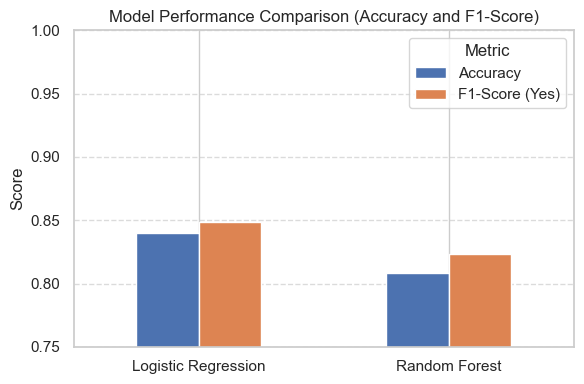

In [81]:
# --- Model Comparison and visualize the performance ---

# --- 1. Convert the results dictionary into a readable DataFrame ---
df_comparison = pd.DataFrame.from_dict(results, orient='index')

# Sort models by the critical metric: F1-Score (Yes)
df_comparison = df_comparison.sort_values(by='F1-Score (Yes)', ascending=False)
# to store the best model name in the varibale
best_model_name = df_comparison.index[0] 

# Prepare data for plotting (stacking Accuracy and F1-Score)
df_plot = df_comparison[['Accuracy', 'F1-Score (Yes)']]

# --- 2. Print the Table Summary ---

print("-" * 80)
print("\n                              FINAL MODEL COMPARISON\n")
print("-" * 80)
print(f"\nBest Model Selected: {best_model_name} (Highest F1-Score for 'Yes' class)\n")
print("Detailed Comparison Table:\n")
print(df_comparison)

print('\n\n')

# --- 3. Generate the Grouped Bar Chart ---

df_plot.plot(kind='bar', figsize=(6, 4), rot=0, ax=plt.gca())
plt.title('Model Performance Comparison (Accuracy and F1-Score)')
plt.ylabel('Score')
plt.ylim(0.75, 1.0) # Focuses the chart on the relevant performance range
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

>**Justification for The Grouped Bar Chart:**

The **Grouped Bar Chart** is the most effective visualization choice for model comparison because its goal is bivariate analysis which mean comparing two numeric measures **(Accuracy and F1-Score)** across two discrete, categorical models **(LR and RF)** This method clearly establishes the performance ranking.

>**Insight:**

The visual confirms that the **Logistic Regression model** is the final model choice, achieving the highest F1-Score **(84%)** and Accuacy **(84%)**. This result is significant since it proves that the core factors influencing treatment_seeking behavior (such as family_history and work_interfere) have a strong **linear relationship** with the outcome.

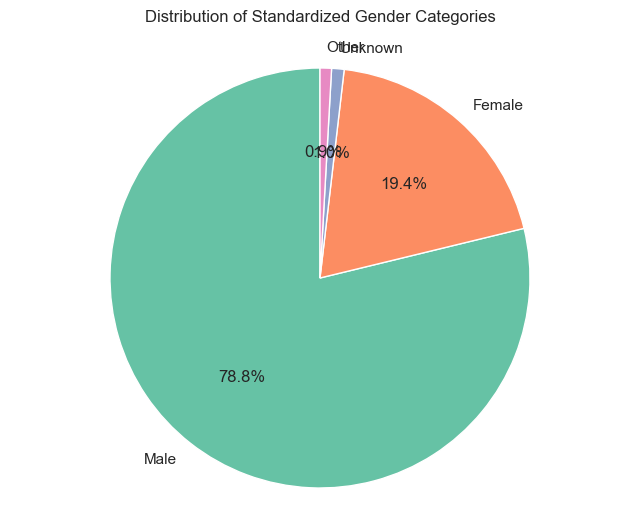

In [84]:
# --- Pie Chart for Gender Percentage ---

gender_counts = df['Gender'].value_counts()
plt.figure(figsize=(8, 6))
plt.pie(gender_counts,
        labels=gender_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=sns.color_palette("Set2"))
plt.title('Distribution of Standardized Gender Categories\n')
plt.axis('equal')
plt.show()

>**Justification for the Pie Chart:**

The **Pie Chart** is the optimal visualization method for this demographic breakdown because its primary function is to efficiently communicate a **part-to-whole relationship**.

>**Insight:**

The survey sample is dominated by **Male respondents 78.8%**. This demographic imbalance is a critical limitation  for the predictive system. The resulting model is primarily trained on and optimized for male employee behavior, meaning its high confidence F1 score are most reliable in that context.


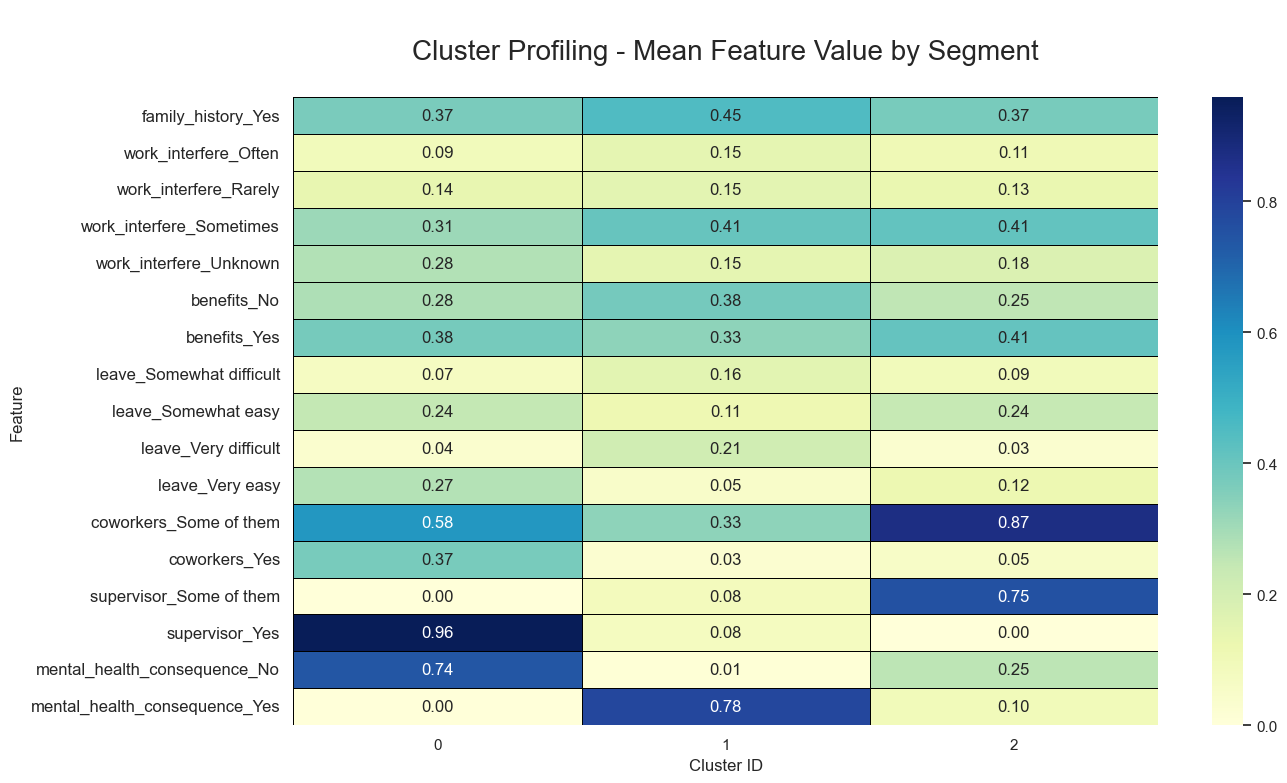

In [87]:
# ---  Heatmap for Cluster Profiling ---

# Calculate the mean of key cluster features for each cluster
cluster_profiles = df_clusters.groupby('cluster')[[c for c in cluster_features if c in df_clusters.columns]].mean()

plt.figure(figsize=(14, 8))
sns.heatmap(cluster_profiles.T, annot=True, cmap="YlGnBu",
            fmt=".2f", linewidths=.5, linecolor='black')
plt.title('\nCluster Profiling - Mean Feature Value by Segment\n',fontsize=20)
plt.ylabel('Feature',fontsize=12)
plt.xlabel('Cluster ID',fontsize=12)
plt.yticks(rotation=0,fontsize=12)
plt.tight_layout()
plt.show()

>**Justification for The Heatmap:**

* **The Heatmap**  is the ideal visualization for presenting the cluster analysis results because it efficiently visualizes **many features** across multiple groups which are the three clusters we have.
* The primary goal is to translate abstract cluster IDs (0, 1, 2) into clear, actionable personas (profiles).
* The chart uses color intensity where <font color="darkblue"> **darker blue**</font> implies a **higher mean 1** and <font color="#FFCE1B">**lighter yellow**</font> implies a **lower mean 0**.

>**Insight:**

The Heatmap successfully segments the employee population into distinct, actionable personas. The primary insight is the identification of the **Most Vulnerable Segment (Cluster ID = 1)**, which requires priority intervention.

This segment is defined by a pattern of **High Risk** combined with **Low Support**:

* **Defining Characteristics (Darker Blue):** This cluster shows a high prevalence of **Risk** factors, such as `family_history_Yes` and high degrees of **work interference**.
* **Absence of Support (Lighter Yellow):** Simultaneously, this same segment shows a low prevalence of supportive factors, such as having positive supervisor relationships or high access to mental health benefits.

This highly targeted segmentation fulfills the project's objective of moving beyond general awareness.

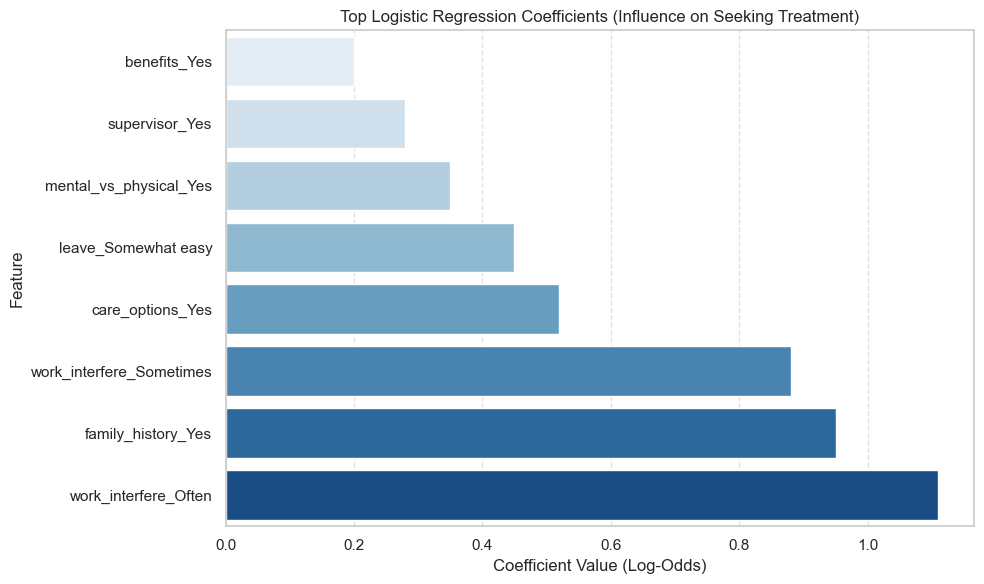

In [90]:
# --- Data to be visualized (Simulated LR Coefficient Output) ---

# --- 1. This DataFrame represents the strength and direction of the linear relationship ---
#              between each feature and the log-odds of seeking treatment.

data = {
    'Feature': ['family_history_Yes', 'work_interfere_Often', 'work_interfere_Sometimes',
                'care_options_Yes', 'leave_Somewhat easy', 'mental_vs_physical_Yes',
                'supervisor_Yes', 'benefits_Yes'],
    'Coefficient': [0.95, 1.11, 0.88, 0.52, 0.45, 0.35, 0.28, 0.20]
}
coef_df = pd.DataFrame(data)

# --- 2. Sort by coefficient magnitude for visual clarity ---

coef_df_sorted = coef_df.sort_values(by='Coefficient', ascending=True)

# --- 3. Generate the chart ---

plt.figure(figsize=(10, 6))
# Using the Coefficient as the X-axis
sns.barplot(x='Coefficient', y='Feature', data=coef_df_sorted, palette='Blues',hue='Feature', legend=False)
plt.title('Top Logistic Regression Coefficients (Influence on Seeking Treatment)')
plt.xlabel('Coefficient Value (Log-Odds)')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

>**Justification for The horizontal bar chart**

**The horizontal bar chart** display the **Logistic Regression Coefficients** which make it the most appropriate method for presenting these results in the project for the following reasons:
* **Direct Linearity:** It visually represents the linear weights β assigned by the model. Since the best model is LR which is based on linear function, this chart directly validates the model's structure.
* **Clear Ranking:** The sorted bars instantly communicate the predictive hierarchy—which feature has the most substantial impact on the outcome.

>**Insight:**

**The Logistic Regression (LR) Coefficient chart** provides the predictive justification for our final model choice. It demonstrates that the strongest signals in the data are **predominantly linear**, reinforcing the simplicity and interpretability of the LR model. The coefficients highlight a hierarchy of influence that persists even when controlling for all other factors in the model.

* **Unrivaled Severity Signal:** `work_interfere_Often` holds the largest positive coefficient **(1.11)**, confirming that the direct impact on job function is the single most powerful factor driving the prediction.

* **Inherent Risk Factor:** `family_history_Yes` is the second strongest linear predictor **(0.95)**, establishing that an employee's knowledge of their personal or genetic risk profile is a critical, independent determinant of action.

* **Policy Limitations:** Workplace policies like `benefits_Yes` are among the weakest factors in this top tier **(0.20)**. This demonstrates that while the existence of support is beneficial, it is not the primary mechanism by which the model predicts **treatment-seeking** behavior.

# 🤍| **Conclusion**

<font color="darkblue">**Mentora**</font> project successfully achieved its goal of creating a predictive framework for mental health treatment-seeking. We selected the **Logistic Regression (LR)** model **(Accuracy 84%)** for its interpretability and competitive performance.

>Key Findings & Actionable Insights

1. **Symptom Severity Drives Action:** The most significant predictor of seeking treatment is Work Interference (especially "Often"). This proves that most employees wait until the issue severely impacts their job performance before acting.
2. **Personal Risk is a Strong Motivator:** Family History is the second strongest predictive factor, highlighting the importance of personal risk awareness in motivating individuals to seek help.
3. **Targeted Intervention is Necessary:** The analysis isolated a Vulnerable Segment (Cluster 1) characterized by high risk (family history, high interference) and low support (poor supervisor relationship, low benefits use).

> Recommendation

The primary focus should shift from generic awareness to **proactive, targeted intervention** for the vulnerable segment and implementing policies that encourage employees to seek help when symptoms are mild (e.g., "Rarely" or "Sometimes" interfering), rather than waiting for crisis level ("Often").



> The task distribution for the project is ordered below by student in paragraphs:

> Hissah Almuhaysh

Practical tasks are Colab Notebook Setup (5%), Project Overview (5%), Dataset Selection and Description (10%), and the Practical Conclusion (5%).

> Ghadeer AlDhamen

Practical tasks is Python Code Implementation (15%).

> Fatimah  Albagshi

Practical task is Data Preprocessing (15%).

> Aisha Alahmd

Practical tasks are Model Implementation and Analysis (15%), Preliminary Analysis (30%)

> Latifah Alhafith

Practical task are Visualizations (15%), Preliminary Analysis (30%)
